In [9]:
import sys
import os
from pathlib import Path
# Go up until you find the project root
while not (Path.cwd() / ".gitignore").exists() and Path.cwd() != Path("/"):
    os.chdir("..")


In [76]:
import geopandas as gpd
import matplotlib.pyplot as plt
import fiona
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np

In [102]:
region = 'awt'  # example region code
group = 'bird'
group_ = '_' if group != '' else ''
gdf_map = gpd.read_file(f'data/raw/NCEAS/Borders/{region}.gpkg')  # path for a .gpkg

# read data\raw\NCEAS\Records\train_po\AWTtrain_po.csv with region variable
df_po = gpd.read_file(f'data/processed/NCEAS/Records/train_po/{region.upper()}train_po{group_}{group}.csv')

# data\raw\NCEAS\Records\test_pa\AWTtest_pa_bird.csv
df_pa = gpd.read_file(f'data/raw/NCEAS/Records/test_pa/{region.upper()}test_pa{group_}{group}.csv')


In [103]:
gdf_points_po = gpd.GeoDataFrame(
    df_po,
    geometry=gpd.points_from_xy(df_po.x, df_po.y),
    crs=str(gdf_map.crs)  # Set CRS (important!)
    )

gdf_points_pa = gpd.GeoDataFrame(
    df_pa,
    geometry=gpd.points_from_xy(df_pa.x, df_pa.y),
    crs=str(gdf_map.crs)  # Set CRS (important!)
    )


In [104]:
def plot_sd(gdf_points_po, gdf_points_pa, gdf_map, title, plot_pa_separately=False):
# Make the figure larger
    fig, ax = plt.subplots(figsize=(10, 10))

    # Base map (GeoPackage layer)
    gdf_map.plot(ax=ax, color="whitesmoke", edgecolor="gray", linewidth=0.5)

    if plot_pa_separately:
        # separate column PA in 0 and 1
        gdf_points_pa_1 = gdf_points_pa[gdf_points_pa['PA'] == 1]
        gdf_points_pa_0 = gdf_points_pa[gdf_points_pa['PA'] == 0]
        # Points layers PA=1
        gdf_points_pa_1.plot(
            ax=ax,
            color="green",
            markersize=4,
            label="PA=1",
            alpha=0.9
        )
        # Points layers PA=0
        gdf_points_pa_0.plot(
            ax=ax,
            color="blue",
            markersize=1,
            label="PA=0",
            alpha=0.3
        )
    else:
            # Points layers PA
        gdf_points_pa.plot(
            ax=ax,
            color="blue",
            markersize=4,
            label="PA",
            alpha=0.6
        )
    # Points layers
    gdf_points_po.plot(
        ax=ax,
        color="red",
        markersize=4,
        label="PO",
        alpha=0.7
    )

    # Add title, labels, legend
    # ax.set_title("PO & PA Points over Base Map", fontsize=16, fontweight="bold")
    ax.set_title(title, fontsize=14)
    # ax.set_xlabel("Longitude", fontsize=12)
    # ax.set_ylabel("Latitude", fontsize=12)
    ax.legend(title="Data Source", loc="upper right")

    # Add grid and frame
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.7)
    ax.set_facecolor("aliceblue")

    # Remove axis spines for a clean look
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Show plot
    plt.tight_layout()
    plt.show()


Species ID: awt01 - PA=1 ratio: 0.27, Total PA points: 340


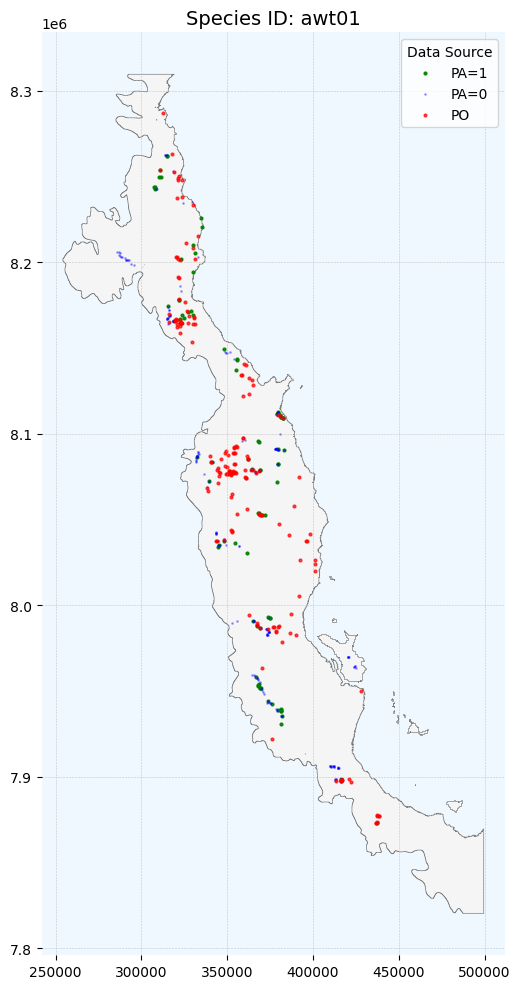

Species ID: awt02 - PA=1 ratio: 0.31, Total PA points: 340


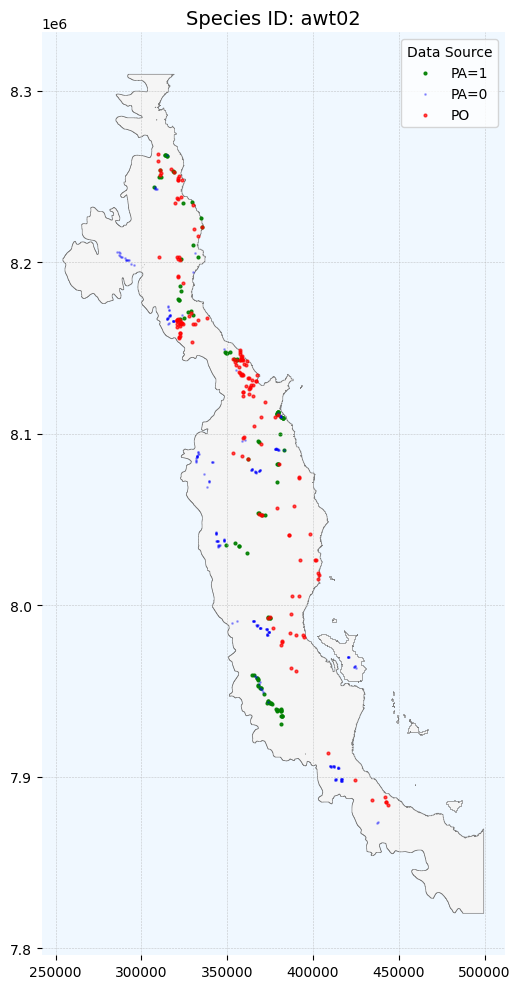

Species ID: awt03 - PA=1 ratio: 0.38, Total PA points: 340


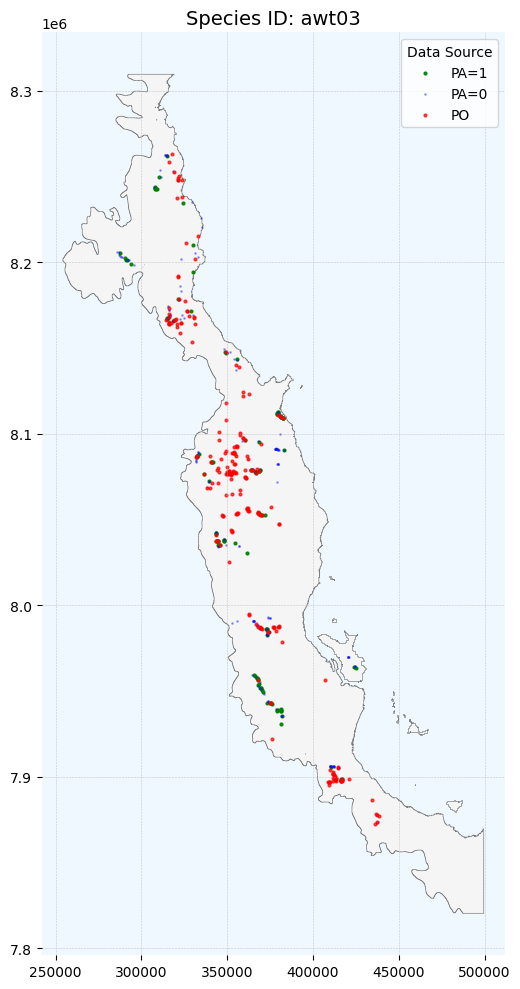

Species ID: awt04 - PA=1 ratio: 0.46, Total PA points: 340


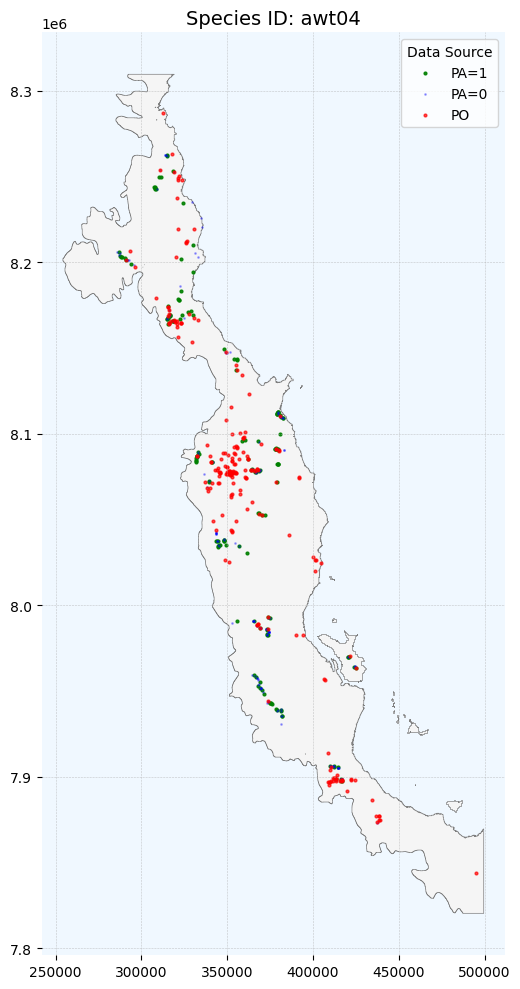

Species ID: awt05 - PA=1 ratio: 0.14, Total PA points: 340


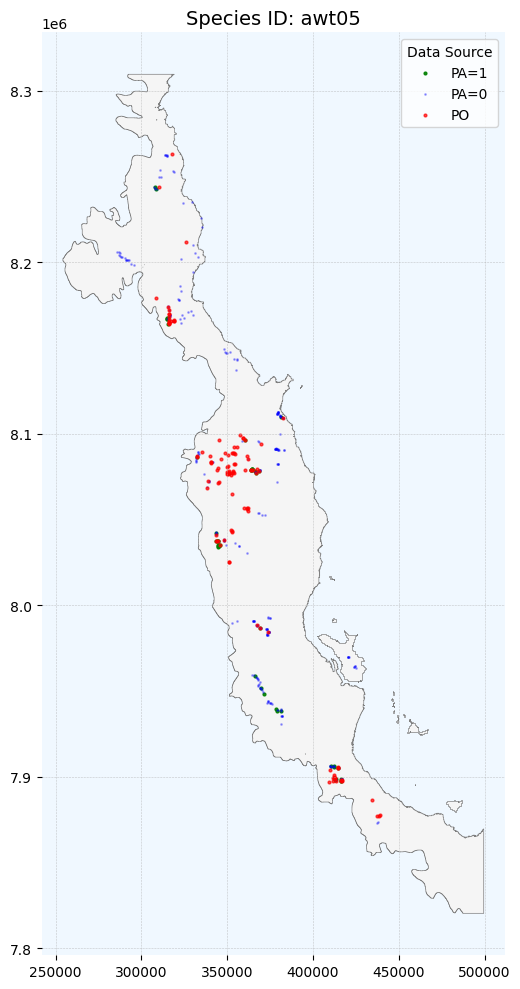

Species ID: awt06 - PA=1 ratio: 0.55, Total PA points: 340


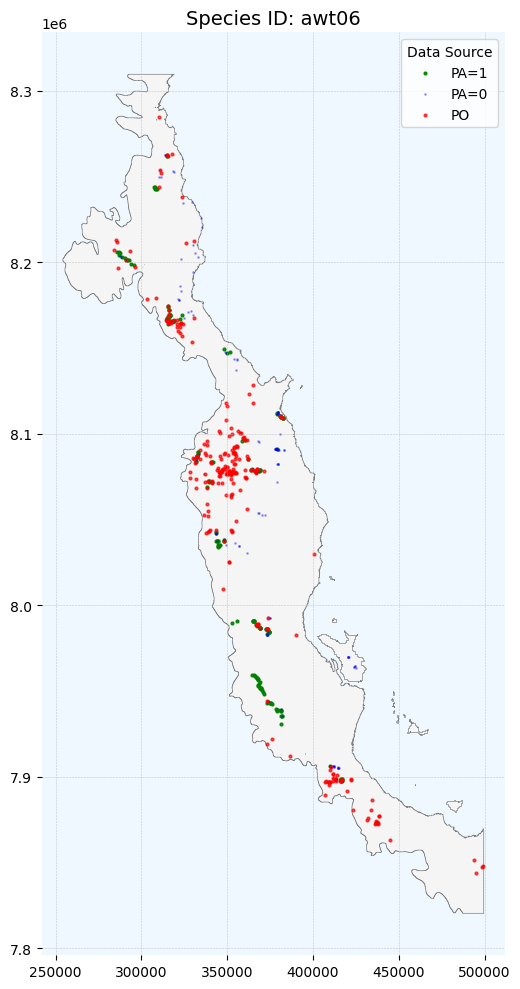

Species ID: awt07 - PA=1 ratio: 0.24, Total PA points: 340


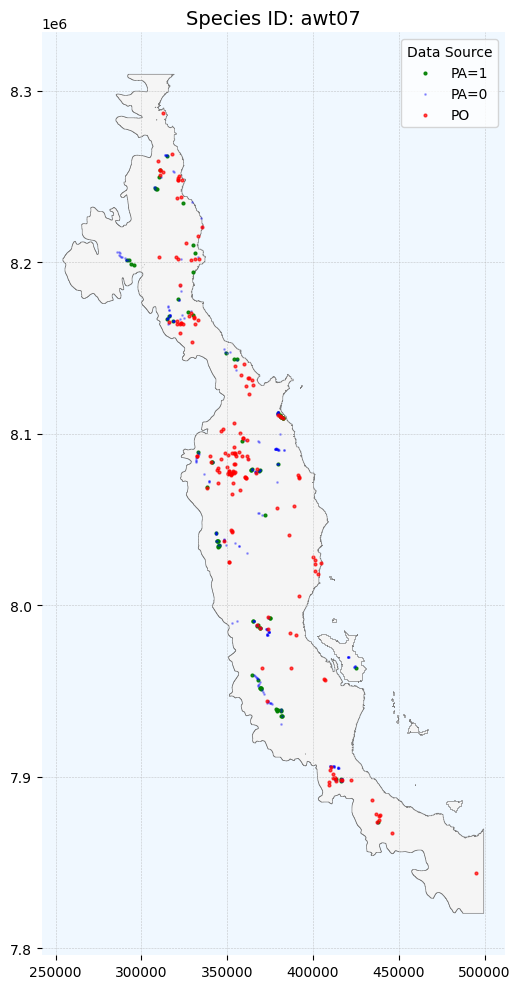

Species ID: awt08 - PA=1 ratio: 0.40, Total PA points: 340


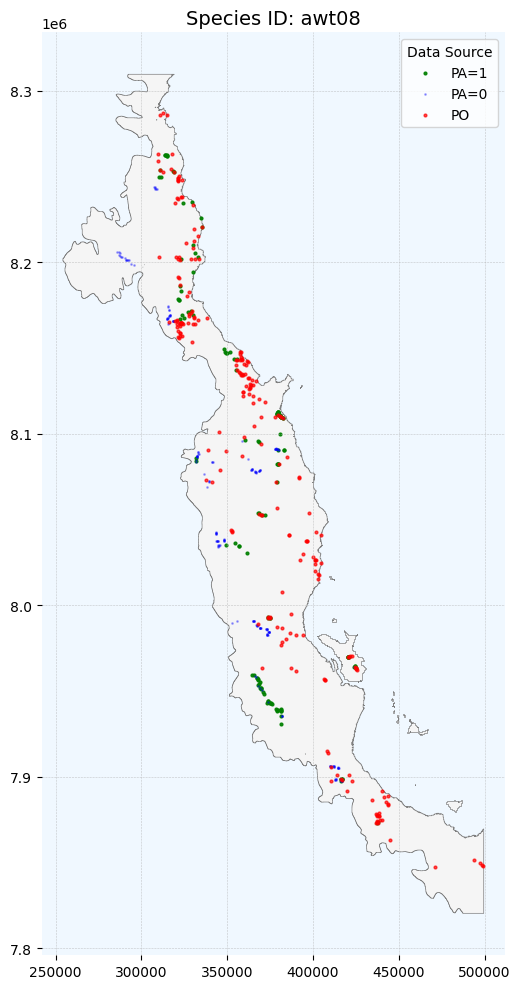

Species ID: awt09 - PA=1 ratio: 0.14, Total PA points: 340


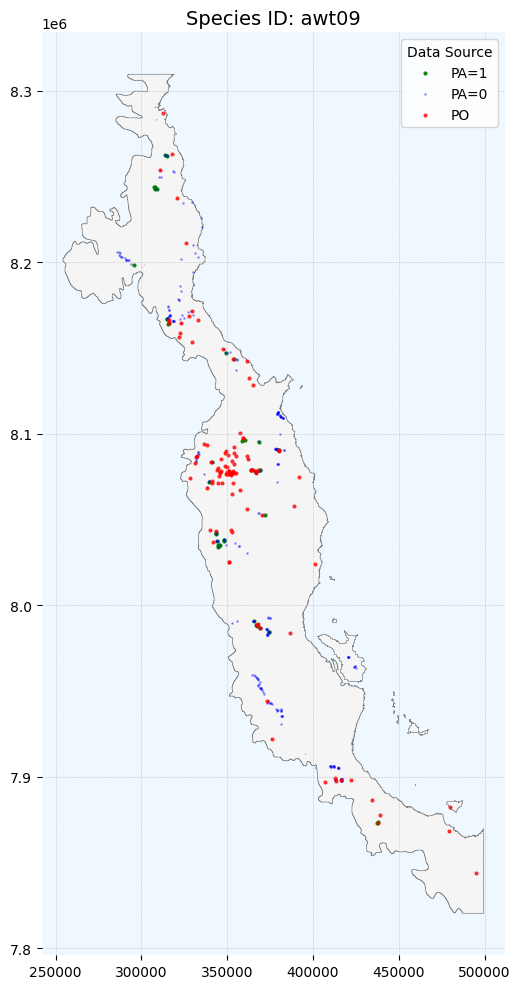

Species ID: awt10 - PA=1 ratio: 0.30, Total PA points: 340


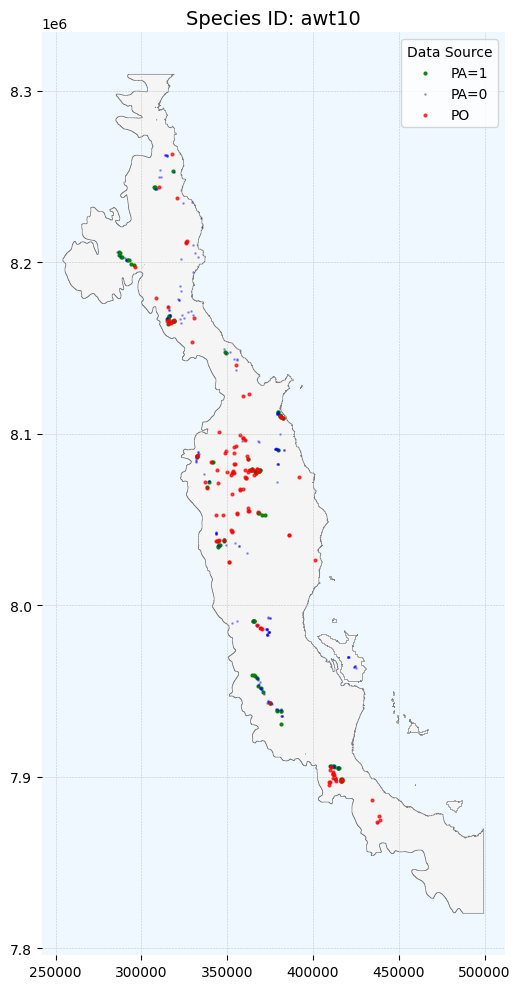

Species ID: awt11 - PA=1 ratio: 0.04, Total PA points: 340


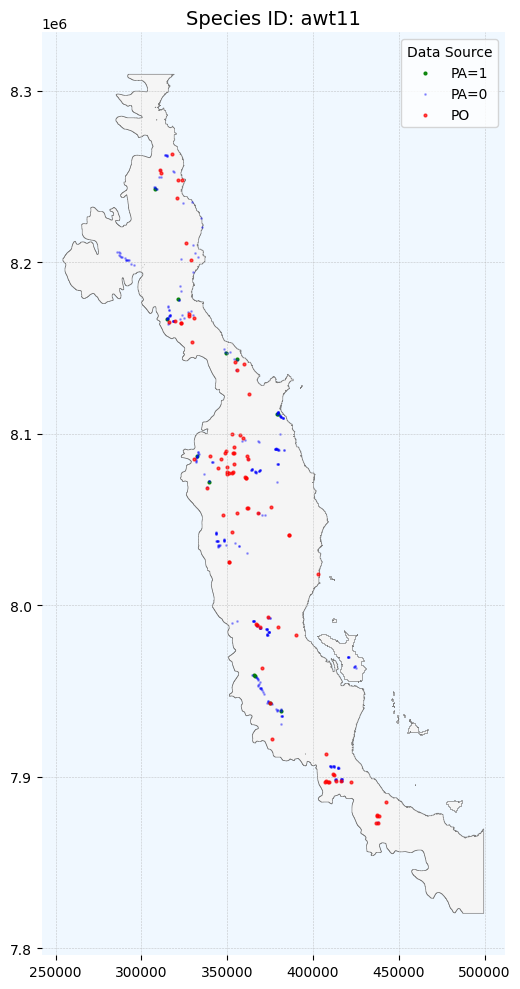

Species ID: awt12 - PA=1 ratio: 0.05, Total PA points: 340


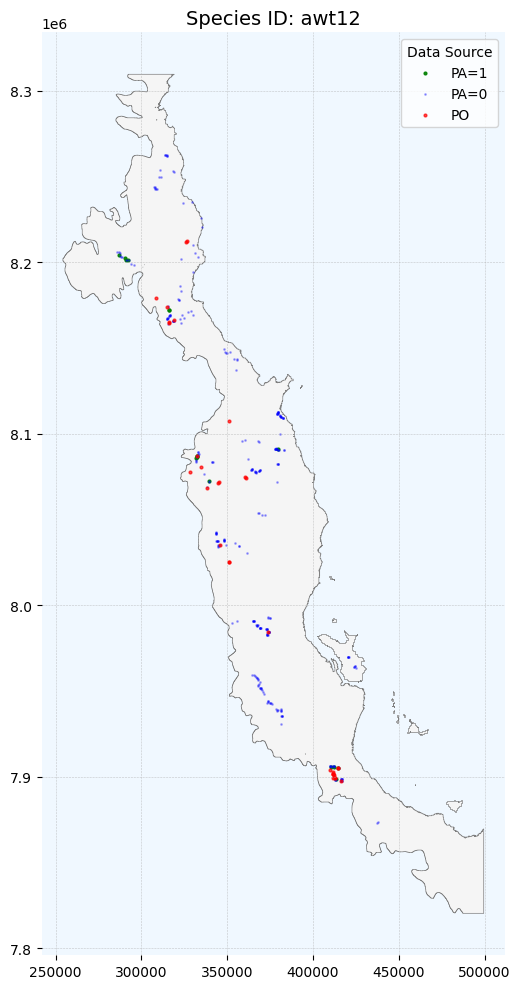

Species ID: awt13 - PA=1 ratio: 0.30, Total PA points: 340


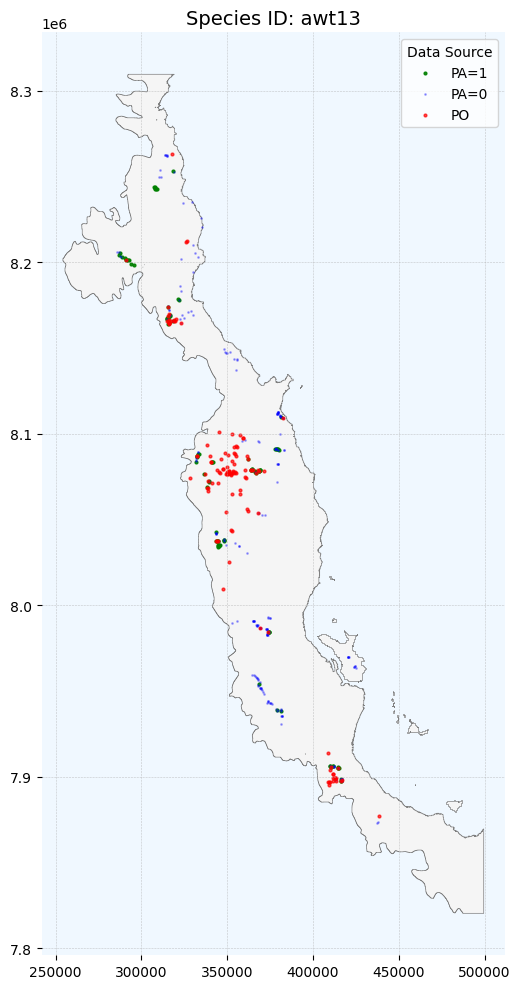

Species ID: awt14 - PA=1 ratio: 0.19, Total PA points: 340


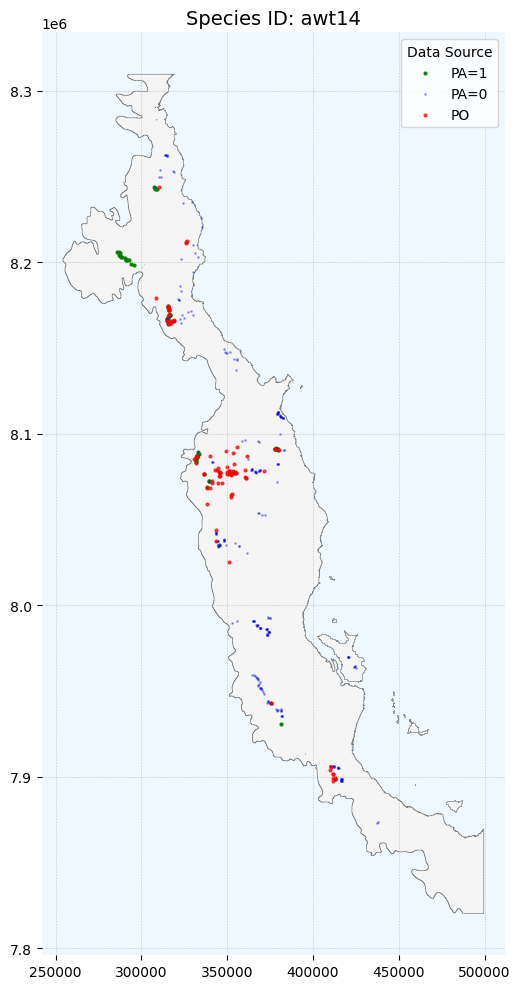

Species ID: awt15 - PA=1 ratio: 0.63, Total PA points: 340


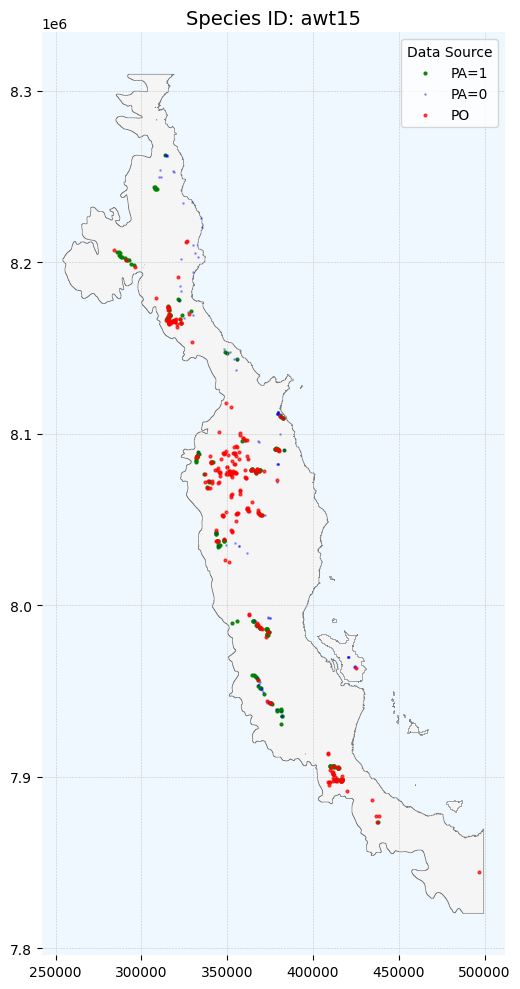

Species ID: awt16 - PA=1 ratio: 0.19, Total PA points: 340


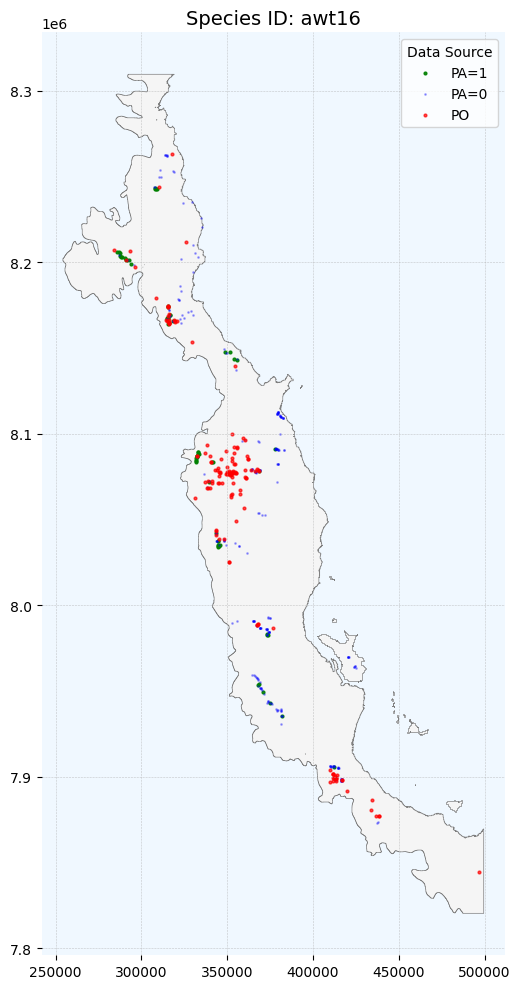

Species ID: awt17 - PA=1 ratio: 0.30, Total PA points: 340


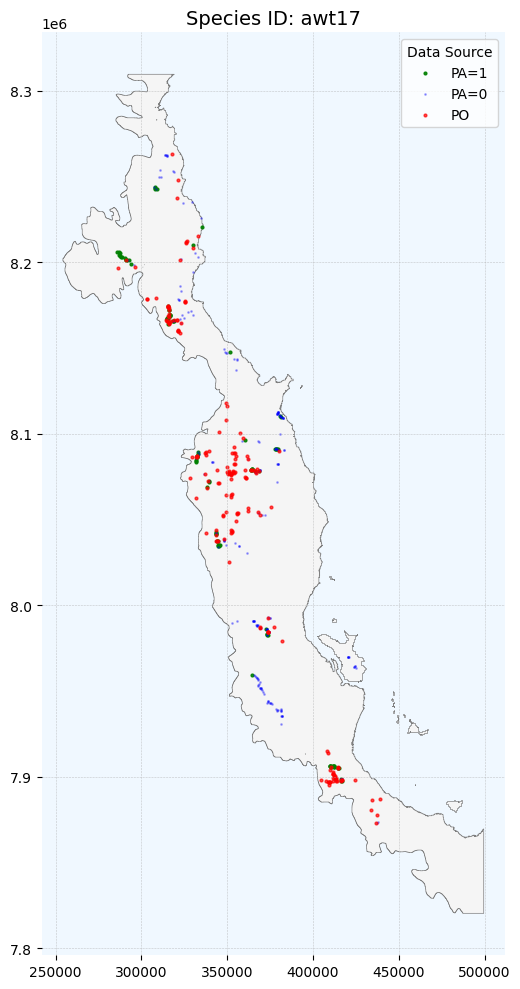

Species ID: awt18 - PA=1 ratio: 0.40, Total PA points: 340


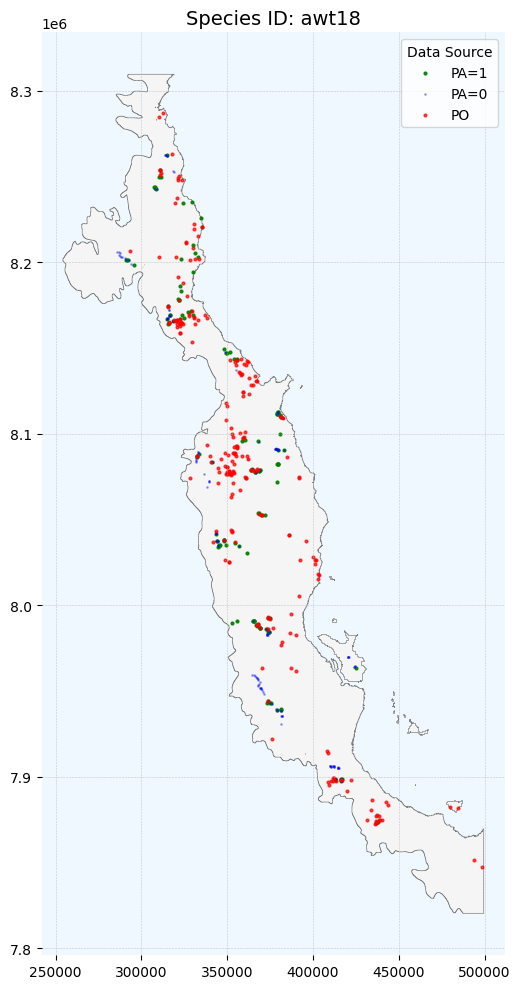

Species ID: awt19 - PA=1 ratio: 0.19, Total PA points: 340


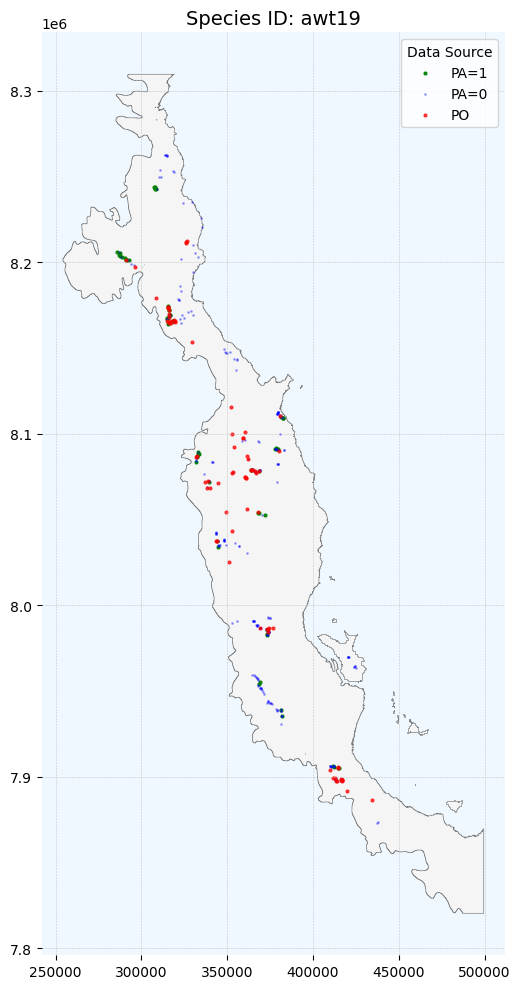

Species ID: awt20 - PA=1 ratio: 0.24, Total PA points: 340


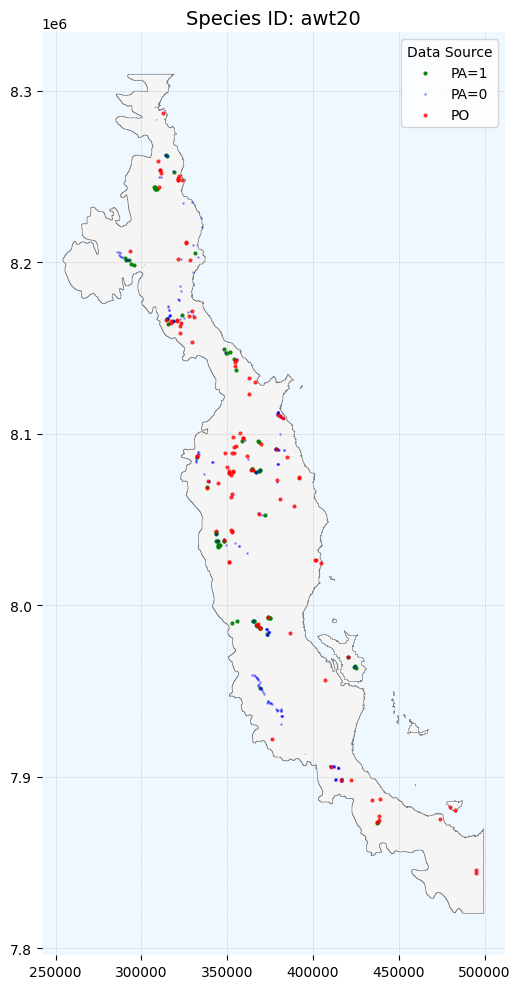

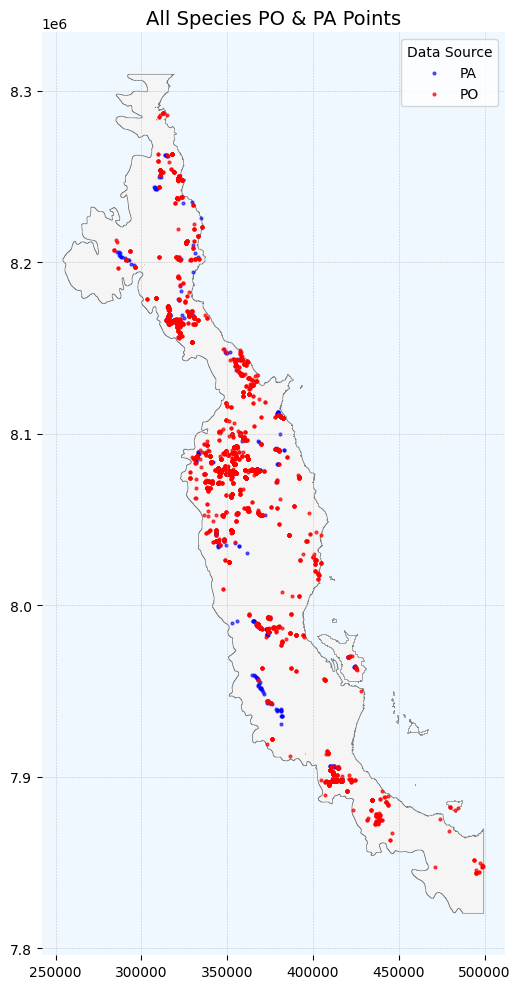

In [105]:
unique_species = gdf_points_po['spid'].unique()
plot_pa_separately = True  # Set to True to plot PA=1 and PA=0 separately

for sp in unique_species:

    gdf_points_po_sp = gdf_points_po[gdf_points_po['spid'] == sp]
    gdf_points_pa_sp = gdf_points_pa.copy()#[gdf_points_pa['spid'] == sp]
    if plot_pa_separately:
        gdf_points_pa_sp['PA'] = gdf_points_pa_sp[sp].astype(int)

    # count how many of the total are PA=1
    ratio = gdf_points_pa_sp['PA'].sum() / len(gdf_points_pa_sp)
    print(f"Species ID: {sp} - PA=1 ratio: {ratio:.2f}, Total PA points: {len(gdf_points_pa_sp)}")

    plot_sd(gdf_points_po_sp, gdf_points_pa_sp, gdf_map, title=f"Species ID: {sp}", plot_pa_separately=plot_pa_separately)

# plot the spatial distribution for all species together
plot_sd(gdf_points_po, gdf_points_pa, gdf_map, title="All Species PO & PA Points")



